In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mini_nn.layers import Linear, ReLu, Softmax
from mini_nn.losses import CrossEnthropyLoss
from mini_nn.optim import SGD
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [2]:
# --- Create multiclass data ---
x, y = make_blobs(
    n_samples=5000,
    centers=4,
    n_features=10,
    cluster_std=1.5,
    random_state=RANDOM_SEED
)

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x,y,
                                                    random_state=RANDOM_SEED,
                                                    test_size=0.2)

y_train = np.eye(4)[y_train]
y_test = np.eye(4)[y_test]

In [4]:
print(f'x_train shape: {x_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (4000, 10)
x_test shape: (1000, 10)
y_train shape: (4000, 4)
y_test shape: (1000, 4)


In [5]:
# --- Build the neural network ---
input_layer = Linear(in_features=x_train.shape[1],
                     out_features=16,
                     initialize='he_normal')
input_relu = ReLu()

linear1 = Linear(in_features=16,
                 out_features=16,
                 initialize='he_normal')
relu1 = ReLu()

out_layer = Linear(in_features=16,
                 out_features=4,
                 initialize='he_normal')
out_soft = Softmax()

# --- Set a loss function ---
loss_func = CrossEnthropyLoss()

# --- Set an optimizer ---
optimizer = SGD(
    layers = [input_layer, linear1, out_layer],
    learning_rate = 0.01
)

In [6]:
# --- Training loop ---
def train_model(x_train, y_train, x_val, y_val, loss_function, optimizer, epochs):

    train_loss_hist = []
    val_loss_hist = []

    for ep in range(epochs):
        # --- forward propagation ---
        x = input_layer(x_train)
        x = input_relu(x)
        x = linear1(x)
        x = relu1(x)
        x = out_layer(x)
        x = out_soft(x)

        # --- evaluate epoch ---
        loss = loss_function(y_train, x)
        train_loss_hist.append(loss)

        # --- back propagation ---
        grad = loss_function.backward()
        grad = out_soft.backward(grad)
        grad = out_layer.backward(grad)
        grad = relu1.backward(grad)
        grad = linear1.backward(grad)
        grad = input_relu.backward(grad)
        grad = input_layer.backward(grad)

        # --- validation test evaluation (forward propagation only) ---
        x = input_layer(x_val)
        x = input_relu(x)
        x = linear1(x)
        x = relu1(x)
        x = out_layer(x)
        x = out_soft(x)

        # --- test set: evaluate epoch ---
        val_loss = loss_function(y_val, x)
        val_loss_hist.append(val_loss)


        # --- optimize ---
        optimizer.step()

        if ep%10 == 0:
            print(
                f'epoch {ep:3d} | train loss={loss:.4f} | validation loss={val_loss:.4f}'
            )

    return train_loss_hist, val_loss_hist

In [10]:
train_loss, val_loss = train_model(x_train, y_train, x_test, y_test, loss_func, optimizer, 2000)

epoch   0 | train loss=0.0003 | validation loss=0.0014
epoch  10 | train loss=0.0003 | validation loss=0.0014
epoch  20 | train loss=0.0003 | validation loss=0.0014
epoch  30 | train loss=0.0003 | validation loss=0.0014
epoch  40 | train loss=0.0003 | validation loss=0.0014
epoch  50 | train loss=0.0003 | validation loss=0.0014
epoch  60 | train loss=0.0003 | validation loss=0.0014
epoch  70 | train loss=0.0003 | validation loss=0.0014
epoch  80 | train loss=0.0003 | validation loss=0.0014
epoch  90 | train loss=0.0003 | validation loss=0.0014
epoch 100 | train loss=0.0003 | validation loss=0.0014
epoch 110 | train loss=0.0003 | validation loss=0.0014
epoch 120 | train loss=0.0003 | validation loss=0.0014
epoch 130 | train loss=0.0003 | validation loss=0.0014
epoch 140 | train loss=0.0003 | validation loss=0.0014
epoch 150 | train loss=0.0003 | validation loss=0.0014
epoch 160 | train loss=0.0003 | validation loss=0.0014
epoch 170 | train loss=0.0003 | validation loss=0.0014
epoch 180 

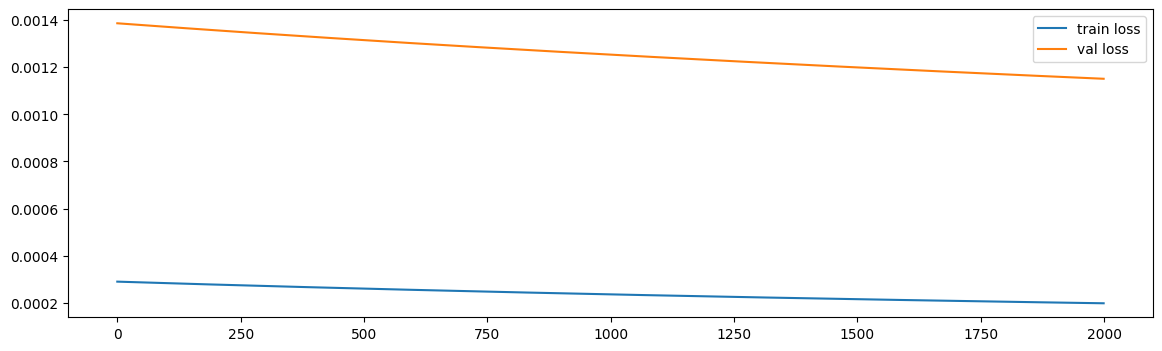

In [11]:
plt.figure(figsize=(14,4))

plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='val loss')

plt.legend()
plt.show()

In [12]:
x_pred = input_layer(x_test)
x_pred = input_relu(x_pred)
x_pred = linear1(x_pred)
x_pred = relu1(x_pred)
x_pred = out_layer(x_pred)
x_pred = out_soft(x_pred)

pred_classes = np.argmax(x_pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

accuracy = np.mean(pred_classes == true_classes)

print("Accuracy:", accuracy)

Accuracy: 1.0
